<a href="https://colab.research.google.com/github/coderboic/simulation/blob/main/sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install gekko


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 123.5 MB/s eta 0:00:00


In [25]:
from gekko import GEKKO
import numpy as np
import pandas as pd


In [26]:
def run_simulation(a, b, x_val):
    m = GEKKO(remote=False)

    x = m.Param(value=x_val)
    y = m.Var()

    m.Equation(y == a * x**2 + b * m.sin(x))
    m.solve(disp=False)

    return y.value[0]


In [27]:
data = []

for _ in range(1000):
    a = np.random.uniform(0.1, 2.0)
    b = np.random.uniform(0.1, 3.0)
    x = np.random.uniform(0, 10)

    y = run_simulation(a, b, x)
    data.append([a, b, x, y])

df = pd.DataFrame(data, columns=["a", "b", "x", "y"])
df.head()


,a,b,x,y
0,1.227933,1.309572,7.106737,62.978292
1,0.285047,2.416556,4.286209,3.036368
2,0.850573,2.269339,1.583551,4.402081
3,1.453595,0.421377,1.896757,5.628769
4,1.405043,1.869529,9.247177,120.475944


In [28]:
X = df[["a", "b", "x"]]
y = df["y"]
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append([
        name,
        mean_squared_error(y_test, preds),
        r2_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
results_df


,Model,MSE,R2
0,Linear Regression,350.220687,0.797077
1,Decision Tree,20.050251,0.988383
2,Random Forest,2.880785,0.998331
3,SVR,419.426023,0.756978
4,Gradient Boosting,6.124209,0.996452


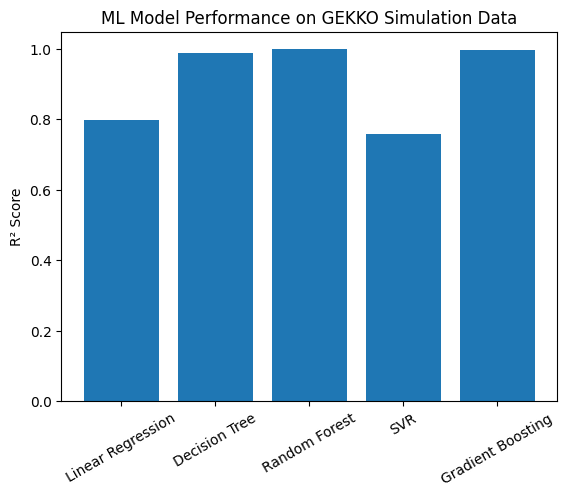

In [29]:
import matplotlib.pyplot as plt

plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R² Score")
plt.title("ML Model Performance on GEKKO Simulation Data")
plt.xticks(rotation=30)
plt.show()